In [15]:
# N=3 Spin System Simulation and Svetlichny's inequality

In [26]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

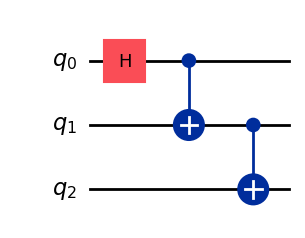

In [17]:
# Defining a GHZ State
def create_ghz_state():
    qc = QuantumCircuit(3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    return qc

display(create_ghz_state().draw('mpl'))


In [ ]:
# Measurment in an arbitary basis

def measure_in_basis(qc, qubit, theta, phi):
    '''
    Rotate the measurement basis to the Z-axis (default basis) and then measure the qubit.
    theta: polar angle
    phi: azimuthal angle
    '''
    qc.rz(-phi, qubit)
    qc.ry(-theta, qubit)
    return qc

In [28]:
# Measuring the Three Spins
# Each observer (Alice, Bob and Charlie) independently chooses a measurement direction. 
# The corresponding rotations are applied before measuring all three qubits.

def simulate(thetaA, phiA, thetaB, phiB, thetaC, phiC, shots=4000):

    qc = create_ghz_state()

    measure_in_basis(qc,0,thetaA,phiA)
    measure_in_basis(qc,1,thetaB,phiB)
    measure_in_basis(qc,2,thetaC,phiC)

    qc.measure_all()

    simulator = AerSimulator()
    qc = transpile(qc, simulator)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts

### Three-Body Correlation Function

For three spins, the correlation function is obtained from the parity of the measurement outcomes. Even parity contributes $+1$ while odd parity contributes $-1$. The expectation value is therefore $E=\dfrac1N\sum_i (-1)^{n_i}N_i,$ where $n_i$ is the number of measured 1's in each bitstring.

In [ ]:
def correlation(thetaA, phiA, thetaB, phiB, thetaC, phiC, shots=4000):

    counts = simulate(thetaA, phiA, thetaB, phiB, thetaC, phiC, shots)
    E = 0

    for bitstring, count in counts.items():
        parity = (-1)**bitstring.count("1")
        E += parity*count

    return E/shots

### Svetlichny's Inequality

For three observers, Alice (A), Bob (B) and Charlie (C), each has two possible measurement settings: $a,a'$, $b,b'$ and $c,c'$.

The Svetlichny parameter is

$S=E(a,b,c)+E(a,b,c')+E(a,b',c)-E(a,b',c')+E(a',b,c)-E(a',b,c')-E(a',b',c)-E(a',b',c').$

Any hybrid local-nonlocal hidden variable theory satisfies $|S|\le4.$ Quantum mechanics predicts a maximum value of $|S|=4\sqrt2\approx5.657,$ demonstrating genuine tripartite nonlocality.

In [29]:
def svetlichny(a, ap, b, bp, c, cp, shots=4096):

    E_abc   = correlation(*a,  *b,  *c,  shots)
    E_abcp  = correlation(*a,  *b,  *cp, shots)
    E_abpc  = correlation(*a,  *bp, *c,  shots)
    E_abpcp = correlation(*a,  *bp, *cp, shots)

    E_apbc   = correlation(*ap, *b,  *c,  shots)
    E_apbcp  = correlation(*ap, *b,  *cp, shots)
    E_apbpc  = correlation(*ap, *bp, *c,  shots)
    E_apbpcp = correlation(*ap, *bp, *cp, shots)

    S = (E_abc + E_abcp + E_abpc - E_abpcp + E_apbc - E_apbcp - E_apbpc - E_apbpcp)

    terms = {
        "E(a,b,c)"      : E_abc,
        "E(a,b,c')"     : E_abcp,
        "E(a,b',c)"     : E_abpc,
        "E(a,b',c')"    : E_abpcp,
        "E(a',b,c)"     : E_apbc,
        "E(a',b,c')"    : E_apbcp,
        "E(a',b',c)"    : E_apbpc,
        "E(a',b',c')"   : E_apbpcp
    }

    return S, terms

In [ ]:
phi = np.linspace(0, 2*np.pi, 30)

S_values = []

theta = np.pi/2

for x in phi:

    a  = (theta, x)
    ap = (theta, x + np.pi/2)

    b  = (theta, x)
    bp = (theta, x + np.pi/2)

    c  = (theta, x - np.pi/4)
    cp = (theta, x + np.pi/4)

    S, terms = svetlichny(a, ap, b, bp, c, cp)

    S_values.append(S)

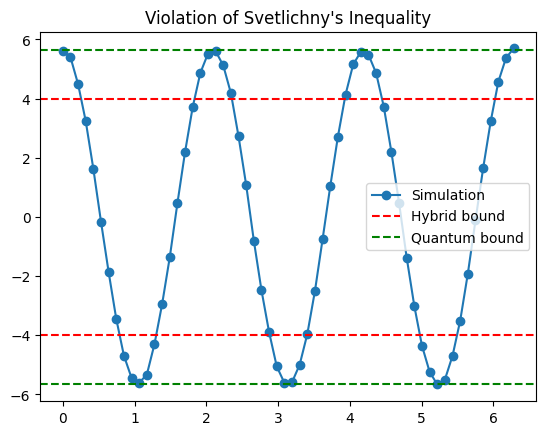

In [ ]:
# Plots 
plt.plot(phi, S_values, 'o-', label='Simulation')

plt.axhline(4, color='red', linestyle='--', label='Hybrid bound')
plt.axhline(-4, color='red', linestyle='--')

plt.axhline(4*np.sqrt(2), color='green', linestyle='--', label='Quantum bound')
plt.axhline(-4*np.sqrt(2), color='green', linestyle='--')

plt.title("Violation of Svetlichny's Inequality")
plt.legend()
plt.show()